In [524]:
# !pip install astropy
# !pip install scikit-image

import os

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

from skimage.draw import ellipse

In [525]:
fits_path = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

catalogue_path = "../data/processed/metadata/cleanedSegregatedMergedCatalogue.txt"

output_file = "../outputs/figures"
output_image_path = "../data/processed/images"
output_mask_path = "../data/processed/masks"

os.makedirs(output_file, exist_ok=True)
os.makedirs("../data/processed/images", exist_ok=True)
os.makedirs("../data/processed/masks", exist_ok=True)


In [526]:
hdul = fits.open(fits_path)
hdul.info()

data = hdul[1].data
header = hdul[1].header

print(data.shape)
print(np.nanmin(data), np.nanmax(data))


Filename: ../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   ()      
  1  SCI           1 ImageHDU        75   (2380, 1177)   float32   
  2  ERR           1 ImageHDU        10   (2380, 1177)   float32   
  3  CON           1 ImageHDU        10   (2380, 1177, 1)   int32   
  4  WHT           1 ImageHDU         9   (2380, 1177)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2380, 1177)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2380, 1177)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2380, 1177)   float32   
  8  HDRTAB        1 BinTableHDU    502   12R x 246C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 70A, 11A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 6A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 7A, 7A, 5A, D, D, D, D, D, D, 27A, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D, D

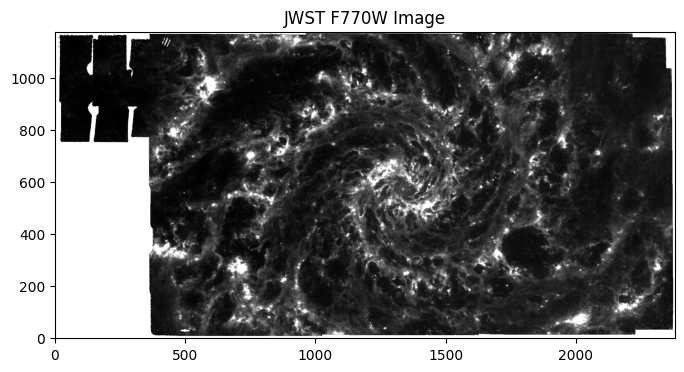

In [527]:
plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.title("JWST F770W Image")
plt.show()

In [528]:
# saving figure to pdf

plt.imsave(
    "../outputs/figures/ngc628_f770w.pdf",
    data, 
    cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

In [529]:
data_clean = np.nan_to_num(data, nan=0.0)

In [530]:
p1, p99 = np.percentile(data_clean, (1, 99))
data_clipped = np.clip(data_clean, p1, p99)

data_norm = (data_clipped - p1) / (p99 - p1)

In [531]:
print (data_norm.shape)
print (data_norm.max())

(1177, 2380)
1.0


In [532]:
# saving ngc 628 png file
output_norm_path = os.path.join(output_image_path, "ngc628Norm.npy")

# Saving normalized image
np.save(output_norm_path, data_norm)

In [533]:
# now sanity check

loaded = np.load(output_norm_path)
print(loaded.shape, loaded.min(), loaded.max())

(1177, 2380) 0.0 1.0


In [534]:
df = pd.read_csv(catalogue_path)

print(df.head())
print(df.columns)

   GLOBAL_ID  ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  \
0         10  10  24d08m59.3s   15d48m6.1s          209          171   
1         12  12   24d09m0.4s  15d47m52.2s          163           93   
2         44  44  24d09m12.5s  15d48m12.1s          144           91   
3         74  74  24d09m17.3s   15d47m3.6s          129           87   
4         98  98  24d09m20.8s   15d48m1.4s          260          187   

   AVG_RAD_PC  PA_DEG  ARM  DIST_ARM_PC  GAL_RAD_KPC CATALOGUE  
0         196       0    3          112         5.04         A  
1         139      20    3           80         4.62         A  
2         127     -60    3           23         4.78         A  
3         115      20    3            7         3.15         A  
4         236      70    3          -74         4.15         A  
Index(['GLOBAL_ID', 'ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC',
       'AVG_RAD_PC', 'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC',
       'CATALOGUE'],
      dtype

In [535]:
def ra_dec_to_deg(ra_str, dec_str):
    coords = SkyCoord(ra=ra_str, dec=dec_str, frame="icrs")
    return coords.ra.deg, coords.dec.deg

ra_degrees, dec_degrees = ra_dec_to_deg(
        df["RA_DMS"].to_numpy(),
        df["DEC_DMS"].to_numpy()
    )


In [536]:
wcs = WCS(header)
print(wcs) 

x_pix, y_pix = wcs.all_world2pix(ra_degrees, dec_degrees, 0)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 24.171680195437894 15.788156932392056
CRPIX : 1176.2406743555237 589.0158147454987
PC1_1 PC1_2  : 0.3421816464879256 -0.939633822723944
PC2_1 PC2_2  : -0.939633822723944 -0.3421816464879256
CDELT : 3.08127265990853e-05 3.08127265990853e-05
NAXIS : 2380  1177


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


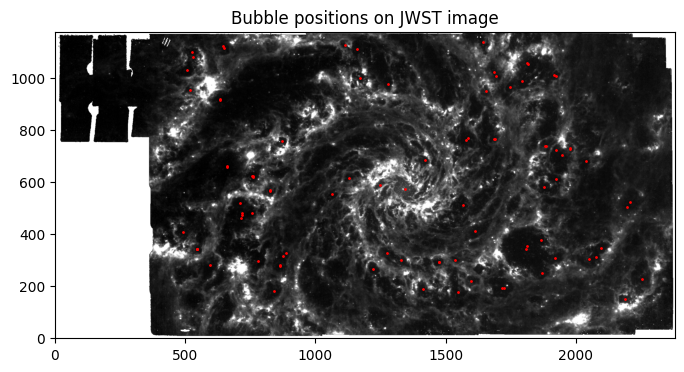

In [537]:
# sanity check  

plt.figure(figsize=(8, 8))

# plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.scatter(x_pix, y_pix, s=1, color='red')
plt.title("Bubble positions on JWST image")

plt.show()

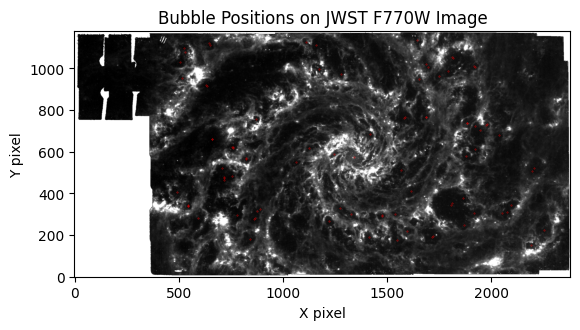

In [538]:
# # saving figure to pdf

plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.scatter(x_pix, y_pix, s=.1, color="red", alpha=0.7)
plt.title("Bubble Positions on JWST F770W Image")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")

output_overlay_path = os.path.join(output_file, "ngc628_f770w_bubble_positions_overlay.pdf")

plt.savefig(
    output_overlay_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [539]:
# mask generation :  parsec to pixel

# Distance to NGC 628 in parsecs
distance_pc = 9.77e6

# Pixel scale from FITS header
pixel_scale_deg = abs(header['CDELT1'])
pixel_scale_arcsec = pixel_scale_deg * 3600

# Physical scale
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc per pixel:", pc_per_pixel)

pc per pixel: 5.254140159227344


In [540]:
mask = np.zeros(data_norm.shape, dtype=np.uint8)     

In [541]:
# semi major and semi minor conversion

semi_major_pix = df['SEMI_MAJ_PC'] / pc_per_pixel
semi_minor_pix = df['SEMI_MIN_PC'] / pc_per_pixel
pa_deg = df['PA_DEG']

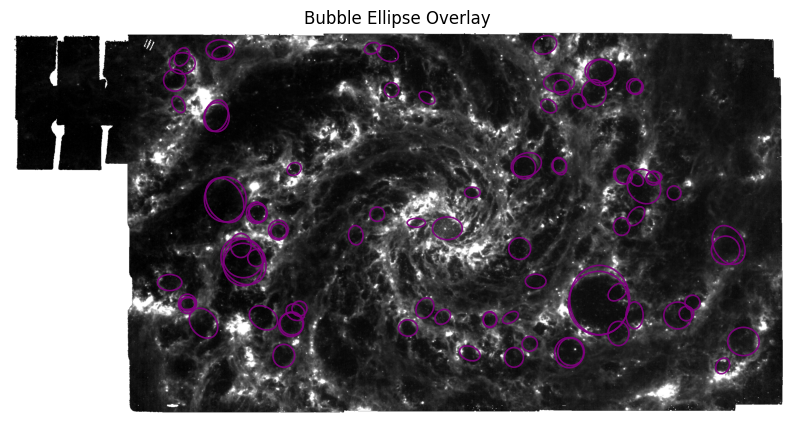

In [542]:

fig, ax = plt.subplots(figsize=(10, 10))

plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    pa = pa_deg.iloc[i]

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    ellipse_patch = Ellipse(
        xy=(x0, y0),
        width=2 * a,
        height=2 * b,
        angle=pa,
        edgecolor="purple",
        facecolor="none",
        linewidth=1.2,
        alpha=0.9,
    )

    ax.add_patch(ellipse_patch)

ax.set_title("Bubble Ellipse Overlay")
ax.set_axis_off()

output_overlay_path = os.path.join(output_file, "ngc628_f770w_bubble_positions.pdf")

plt.savefig(
    output_overlay_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [543]:
for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    pa = np.deg2rad(pa_deg.iloc[i])

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    rr, cc = ellipse(
        r=y0,
        c=x0,
        r_radius=b,
        c_radius=a,
        rotation=pa,
        shape=mask.shape
    )

    mask[rr, cc] = 1

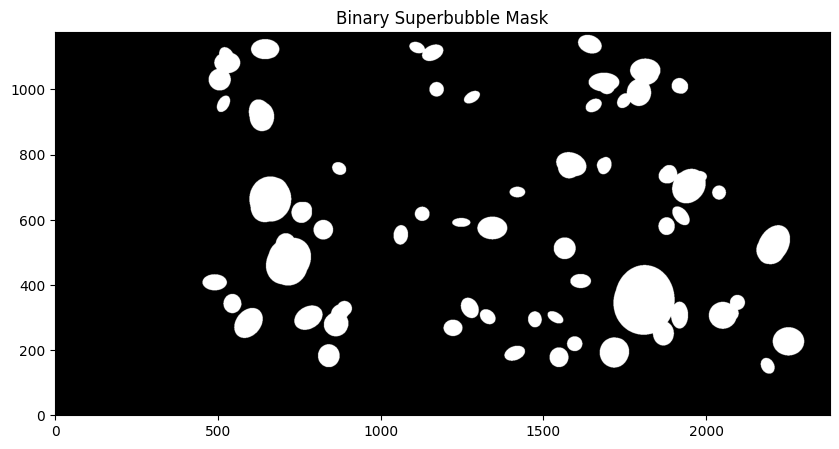

In [544]:
plt.figure(figsize=(10, 10))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask")

overlayabc_path = os.path.join(output_file,"ngc628MaskABC.pdf")

plt.savefig(overlayabc_path, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(mask, origin="lower", alpha=0.35)
plt.title("Superbubble Mask Overlay JWST F770W - ABC catalogue")

overlayabc_path = os.path.join(output_file,"ngc628NormMaskOverlayABC.png")

plt.savefig(overlayabc_path, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# saving mask overlay png file

plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)
    
plt.title("Superbubble Mask Overlay JWST F770W - ABC catalogue")

output_maskoverlay_path = os.path.join(output_file, "ngc628MaskOverlayABC.pdf")

plt.savefig(
    output_maskoverlay_path,
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

# Saving normalized mask
np.save(os.path.join(output_mask_path, "ngc628NormMask.npy"), mask)